In [40]:
!pip install transformers

In [41]:
!pip install seaborn

In [42]:
import os
import pandas as pd
from pathlib import Path
import ast

# 1. Definimos las rutas subiendo un nivel ('..')
# Si el notebook está en /notebooks, '..' nos saca a la raíz del proyecto
BASE_DIR = Path("..").resolve() 

TSV_PILOTO = BASE_DIR / "data" / "pilot_tracks.tsv"
AUDIO_DIR = BASE_DIR / "data" / "audio"
TSV_FULL = BASE_DIR / "mtg-jamendo-dataset" / "data" / "autotagging_moodtheme.tsv"

print(f"Buscando archivos desde la raíz: {BASE_DIR}")

# 2. Carga del subset de 200 canciones
if not TSV_PILOTO.exists():
    print(f"ERROR: No encuentro el TSV en {TSV_PILOTO}")
    # Plan B: Si por lo que sea no detecta el '..', probamos ruta absoluta manual
    print("Intentando localizar la carpeta de trabajo actual:", Path.cwd())
else:
    df_piloto = pd.read_csv(TSV_PILOTO, sep='\t')
    # Convertimos los tags de string "['happy']" a lista real
    df_piloto['tags'] = df_piloto['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
    print(f"Cargadas las {len(df_piloto)} canciones del piloto.")

# ── 3. CARGA DE LAS 59 ETIQUETAS (Usando tu lógica del EDA) ──
etiquetas_jamendo = set()

if TSV_FULL.exists():
    with open(TSV_FULL, 'r', encoding='utf-8') as f:
        for line in f:
            # 1. Saltamos comentarios
            if line.startswith('#'):
                continue
            
            # 2. Tu lógica de split y filtrado
            parts = line.strip().split('\t')
            
            # Cogemos de la columna 5 en adelante y limpiamos
            # Usamos tu línea exacta:
            tags_en_linea = [t.replace('mood/theme---', '') for t in parts[5:] if t.startswith('mood/theme---')]
            
            # Añadimos al set global
            for tag in tags_en_linea:
                etiquetas_jamendo.add(tag)

    etiquetas_jamendo = sorted(list(etiquetas_jamendo))
    
    print(f"Etiquetas extraídas con tu lógica oficial.")
    print(f"Total de emociones únicas detectadas: {len(etiquetas_jamendo)}")
    print(f"Ejemplo de etiquetas: {etiquetas_jamendo[:5]}")
    
    if len(etiquetas_jamendo) == 59:
        print("¡Perfecto! Coincide con las 59 del primer análisis.")
else:
    print(f"No se encontró el TSV en {TSV_FULL}")

Buscando archivos desde la raíz: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE MURCIA\Escritorio\CIENCIA DE DATOS RUBEN\CUARTO\TFG_Emociones
Cargadas las 200 canciones del piloto.
Etiquetas extraídas con tu lógica oficial.
Total de emociones únicas detectadas: 59
Ejemplo de etiquetas: ['action', 'adventure', 'advertising', 'ambiental', 'background']
¡Perfecto! Coincide con las 59 del primer análisis.


In [43]:
import torch
from transformers import ClapModel, ClapProcessor
import numpy as np
from tqdm import tqdm

# ── 1. CONFIGURACIÓN DEL MODELO Y DISPOSITIVO ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

print("Cargando modelo CLAP (esto puede tardar un poco la primera vez)...")
model_id = "laion/clap-htsat-unfused"
processor = ClapProcessor.from_pretrained(model_id)
model = ClapModel.from_pretrained(model_id).to(device)
model.eval()

# ── 2. CÁLCULO DE LA MATRIZ DE TEXTO (Experimento: Prompt Único) ──
# Usamos solo la instrucción más directa para aislar el concepto
plantillas = [
    "A {} song."
]

print("Generando embeddings maestros para las 59 emociones...")
text_embeddings_maestros = []

with torch.no_grad():
    for emocion in tqdm(etiquetas_jamendo, desc="Procesando Emociones"):
        # Prompt Ensembling: media de 5 frases para mayor precisión
        frases = [p.format(emocion) for p in plantillas]
        inputs = processor(text=frases, return_tensors="pt", padding=True).to(device)
        
        embeddings = model.get_text_features(**inputs)
        embedding_medio = embeddings.mean(dim=0)
        embedding_medio = embedding_medio / embedding_medio.norm(dim=-1, keepdim=True)
        text_embeddings_maestros.append(embedding_medio)

# Aquí creamos la variable que faltaba
text_features_matrix = torch.stack(text_embeddings_maestros)
print(f"Matriz de texto lista: {text_features_matrix.shape}")

Usando dispositivo: cuda
Cargando modelo CLAP (esto puede tardar un poco la primera vez)...
Generando embeddings maestros para las 59 emociones...


Procesando Emociones: 100%|██████████| 59/59 [00:00<00:00, 69.17it/s]

Matriz de texto lista: torch.Size([59, 512])


In [44]:
from tqdm import tqdm
import librosa

# ── 3. EVALUACIÓN ZERO-SHOT DEL PILOTO ──
all_probs = []
all_targets = []
errores_lectura = 0

print("Analizando audios con CLAP...")

# Creamos el diccionario para pasar de texto a índice one-hot
label2idx = {label: i for i, label in enumerate(etiquetas_jamendo)}

for idx, row in tqdm(df_piloto.iterrows(), total=len(df_piloto), desc="Zero-Shot Inferring"):
    track_path = AUDIO_DIR / row['path']
    
    # 1. Crear vector objetivo real (One-Hot de 59 clases)
    target_vector = np.zeros(len(etiquetas_jamendo))
    for tag in row['tags']:
        if tag in label2idx:
            target_vector[label2idx[tag]] = 1.0
            
    try:
        # 2. Cargar audio (CLAP usa 48kHz por defecto)
        audio_data, sr = librosa.load(track_path, sr=48000, duration=30) # Evaluamos los primeros 30s
        
        # 3. Extraer Audio Embedding
        audio_inputs = processor(audio=audio_data, return_tensors="pt", sampling_rate=48000)
        audio_inputs = {k: v.to(device) for k, v in audio_inputs.items()}
        
        with torch.no_grad():
            audio_embedding = model.get_audio_features(**audio_inputs)
            audio_embedding = audio_embedding / audio_embedding.norm(dim=-1, keepdim=True)
            
        # 4. Calcular Similitud Coseno (Magia matemática multimodial)
        similitud = audio_embedding @ text_features_matrix.T
        
        # Convertir similitud geométrica a probabilidades
        probabilidades = similitud.softmax(dim=-1)[0].cpu().numpy()
        
        all_probs.append(probabilidades)
        all_targets.append(target_vector)
        
    except Exception as e:
        # Solo imprimimos el primer error para no colapsar el notebook
        if errores_lectura == 0:
            print(f"Error en la primera canción ({track_path}):")
            print(f"Tipo de error: {type(e).__name__}")
            print(f"Mensaje: {e}")
        
        errores_lectura += 1
        continue

print(f"\nAnálisis completado. Errores de lectura de audio: {errores_lectura}")

# Convertimos a matrices Numpy
y_score = np.array(all_probs)
y_true = np.array(all_targets)

Analizando audios con CLAP...


Zero-Shot Inferring: 100%|██████████| 200/200 [00:21<00:00,  9.39it/s]


Análisis completado. Errores de lectura de audio: 0


In [45]:
print(f"Canciones procesadas con éxito: {len(all_targets)}")
if len(all_targets) > 0:
    print(f"Forma de y_true: {np.array(all_targets).shape}")
    print(f"Forma de y_score: {np.array(all_probs).shape}")
else:
    print("¡Cero canciones procesadas! El bucle de inferencia falló en todas.")

Canciones procesadas con éxito: 200
Forma de y_true: (200, 59)
Forma de y_score: (200, 59)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_24924\4224622650.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=auc_df.head(10), x='AUC', y='Emotion', ax=ax1, palette="Greens_r")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_24924\4224622650.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=auc_df.tail(10), x='AUC', y='Emotion', ax=ax2, palette="Reds_r")


Calculando métricas de rendimiento...
ROC-AUC Macro Oficial (Zero-Shot Piloto): 0.6620


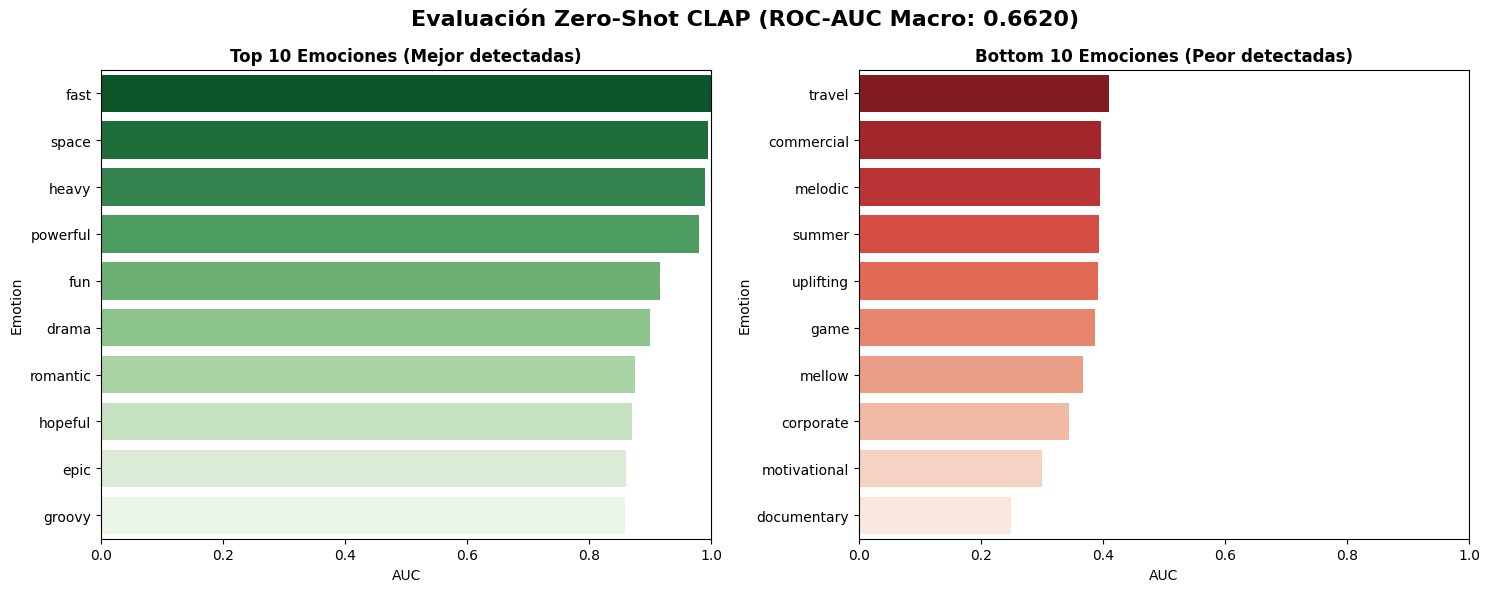

In [46]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── 4. MÉTRICAS SOTA (ROC-AUC) ──
print("Calculando métricas de rendimiento...")

# En un piloto de 200, habrá emociones (como 'harpsichord' o 'christmas') que NO aparezcan 
# ni una sola vez. Si intentamos calcular AUC de esas, sklearn dará error.
# Filtramos solo las columnas donde hay al menos una canción con esa emoción.

valid_cols = [i for i in range(y_true.shape[1]) if len(np.unique(y_true[:, i])) > 1]
etiquetas_validas = [etiquetas_jamendo[i] for i in valid_cols]

# Calculamos AUC por clase y AUC Macro
auc_scores = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average=None)
roc_auc_macro = roc_auc_score(y_true[:, valid_cols], y_score[:, valid_cols], average='macro')

print(f"ROC-AUC Macro Oficial (Zero-Shot Piloto): {roc_auc_macro:.4f}")

# Visualización del Top 10 y Bottom 10
auc_df = pd.DataFrame({'Emotion': etiquetas_validas, 'AUC': auc_scores})
auc_df = auc_df.sort_values(by='AUC', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Top 10
sns.barplot(data=auc_df.head(10), x='AUC', y='Emotion', ax=ax1, palette="Greens_r")
ax1.set_title('Top 10 Emociones (Mejor detectadas)', fontweight='bold')
ax1.set_xlim(0, 1)

# Bottom 10
sns.barplot(data=auc_df.tail(10), x='AUC', y='Emotion', ax=ax2, palette="Reds_r")
ax2.set_title('Bottom 10 Emociones (Peor detectadas)', fontweight='bold')
ax2.set_xlim(0, 1)

plt.suptitle(f'Evaluación Zero-Shot CLAP (ROC-AUC Macro: {roc_auc_macro:.4f})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
import numpy as np

# 1. CONFIGURACIÓN DE PANDAS (Para que no corte el texto)
pd.set_option('display.max_colwidth', None)  # Ver todo el texto de la celda
pd.set_option('display.max_rows', 50)        # Ver más filas si quieres

def generar_tabla_detallada(n_ejemplos=10):
    resultados = []
    
    # Seleccionamos una muestra (puedes cambiarlo a .sample si quieres variedad)
    indices = range(min(n_ejemplos, len(all_targets)))
    
    for i in indices:
        # --- REALIDAD ---
        indices_reales = np.where(y_true[i] == 1)[0]
        reales = [etiquetas_jamendo[idx] for idx in indices_reales]
        
        # --- PREDICCIÓN ---
        # Cogemos el Top 10 para ver el panorama completo
        top_n = 10
        indices_sorted = np.argsort(y_score[i])[::-1]
        top_indices = indices_sorted[:top_n]
        
        preds_list = []
        for rank, idx in enumerate(top_indices):
            nombre = etiquetas_jamendo[idx]
            prob = y_score[i][idx]
            # Marcamos con un ⭐ si esta predicción es una de las reales
            marca = "⭐" if nombre in reales else ""
            preds_list.append(f"{marca}{rank+1}. {nombre} ({prob:.3f})")

        # --- ANÁLISIS DE "DONDE ESTÁ LA VERDAD" ---
        # Si la etiqueta real no está en el Top 10, buscamos en qué posición quedó
        posiciones_verdad = []
        for r_label in reales:
            idx_label = label2idx[r_label]
            pos = np.where(indices_sorted == idx_label)[0][0] + 1
            posiciones_verdad.append(f"{r_label} (Pos: {pos})")

        resultados.append({
            'Track ID': df_piloto.iloc[i]['path'].split('/')[-1],
            'ETIQUETAS REALES': ", ".join(reales),
            f'TOP {top_n} PREDICCIONES CLAP': "  |  ".join(preds_list),
            'RANKING DE LA VERDAD': " / ".join(posiciones_verdad)
        })

    return pd.DataFrame(resultados)

# Ejecutar y mostrar
tabla_detallada = generar_tabla_detallada(n_ejemplos=10)
display(tabla_detallada)

,Track ID,ETIQUETAS REALES,TOP 10 PREDICCIONES CLAP,RANKING DE LA VERDAD
0,719852.mp3,"retro, soft",1. sport (0.020) | 2. groovy (0.020) | 3. fun (0.019) | 4. upbeat (0.019) | 5. cool (0.019) | 6. action (0.019) | 7. fast (0.019) | 8. happy (0.018) | 9. travel (0.018) | 10. documentary (0.018),retro (Pos: 31) / soft (Pos: 53)
1,83260.mp3,ambiental,1. dramatic (0.021) | 2. drama (0.021) | 3. dark (0.020) | 4. travel (0.020) | 5. emotional (0.020) | 6. deep (0.020) | 7. horror (0.019) | 8. epic (0.019) | 9. trailer (0.019) | 10. powerful (0.019),ambiental (Pos: 14)
2,1122449.mp3,emotional,1. meditative (0.020) | 2. motivational (0.019) | 3. sad (0.019) | ⭐4. emotional (0.019) | 5. drama (0.019) | 6. dream (0.019) | 7. inspiring (0.019) | 8. mellow (0.019) | 9. travel (0.019) | 10. christmas (0.019),emotional (Pos: 4)
3,1099784.mp3,energetic,1. commercial (0.020) | 2. motivational (0.020) | 3. advertising (0.019) | 4. sexy (0.019) | 5. funny (0.019) | 6. dark (0.019) | 7. powerful (0.019) | 8. ballad (0.019) | 9. trailer (0.019) | 10. party (0.019),energetic (Pos: 22)
4,1079785.mp3,christmas,1. funny (0.020) | 2. ballad (0.020) | 3. happy (0.020) | 4. fun (0.019) | 5. sport (0.019) | 6. movie (0.018) | 7. drama (0.018) | 8. groovy (0.018) | 9. positive (0.018) | 10. film (0.018),christmas (Pos: 26)
5,889185.mp3,deep,1. epic (0.020) | 2. dark (0.020) | 3. heavy (0.019) | 4. powerful (0.019) | ⭐5. deep (0.019) | 6. action (0.019) | 7. dramatic (0.019) | 8. sad (0.018) | 9. space (0.018) | 10. drama (0.018),deep (Pos: 5)
6,665105.mp3,space,⭐1. space (0.021) | 2. deep (0.021) | 3. soundscape (0.020) | 4. horror (0.020) | 5. dark (0.019) | 6. epic (0.019) | 7. travel (0.019) | 8. dramatic (0.019) | 9. ambiental (0.019) | 10. film (0.019),space (Pos: 1)
7,1407657.mp3,"happy, melodic, upbeat",1. dramatic (0.020) | 2. epic (0.020) | 3. dark (0.020) | 4. drama (0.019) | 5. adventure (0.019) | 6. powerful (0.019) | 7. sad (0.019) | 8. sport (0.019) | 9. movie (0.019) | 10. action (0.019),happy (Pos: 34) / melodic (Pos: 52) / upbeat (Pos: 28)
8,541015.mp3,dark,1. relaxing (0.021) | 2. ambiental (0.020) | 3. calm (0.020) | 4. nature (0.020) | 5. soundscape (0.020) | 6. documentary (0.020) | 7. meditative (0.019) | 8. background (0.019) | 9. travel (0.019) | 10. slow (0.019),dark (Pos: 24)
9,1294621.mp3,party,1. sport (0.019) | 2. fun (0.019) | 3. cool (0.019) | 4. fast (0.019) | 5. action (0.019) | 6. corporate (0.018) | 7. retro (0.018) | 8. deep (0.018) | 9. background (0.018) | 10. inspiring (0.018),party (Pos: 41)


In [48]:
from sklearn.metrics import label_ranking_average_precision_score, coverage_error

# ── 4.2 INFORME DE MÉTRICAS SOTA (Ranking) ──
def calcular_metricas_sota(y_true, y_score):
    # 1. Top-K Accuracy (Lo que ya calculamos, pero consolidado)
    def top_k_acc(k):
        hits = 0
        for i in range(len(y_true)):
            reales = np.where(y_true[i] == 1)[0]
            preds = np.argsort(y_score[i])[::-1][:k]
            if any(p in reales for p in preds): hits += 1
        return (hits / len(y_true)) * 100

    # 2. LRAP (Label Ranking Average Precision)
    # Mide qué tan alto en el ranking están las etiquetas verdaderas. 1.0 es perfecto.
    lrap = label_ranking_average_precision_score(y_true, y_score)
    
    # 3. Coverage Error
    # Cuántas etiquetas (en promedio) hay que recorrer para encontrar todas las reales.
    cov_error = coverage_error(y_true, y_score)

    print("INFORME DE RENDIMIENTO SOTA (Zero-Shot CLAP)")
    print("="*50)
    print(f"ROC-AUC (Macro):           {roc_auc_macro:.4f}")
    print(f"mAP (Ranking Precision):    {lrap:.4f}")
    print(f"Coverage Error:            {cov_error:.2f} (de 59 clases)")
    print("-" * 50)
    print(f"Accuracy @ Top-1:          {top_k_acc(1):.2f}%")
    print(f"Accuracy @ Top-3:          {top_k_acc(3):.2f}%")
    print(f"Accuracy @ Top-5:          {top_k_acc(5):.2f}%")
    print("="*50)
    
    # Guardamos en un pequeño diccionario para comparar luego con PANNs
    return {
        'auc': roc_auc_macro,
        'map': lrap,
        'top1': top_k_acc(1),
        'top5': top_k_acc(5)
    }

metricas_finales = calcular_metricas_sota(y_true, y_score)

INFORME DE RENDIMIENTO SOTA (Zero-Shot CLAP)
ROC-AUC (Macro):           0.6620
mAP (Ranking Precision):    0.1732
Coverage Error:            26.59 (de 59 clases)
--------------------------------------------------
Accuracy @ Top-1:          9.50%
Accuracy @ Top-3:          20.50%
Accuracy @ Top-5:          29.50%


In [49]:
# ── 5. TABLA DE AUDITORÍA DETALLADA (200 ejemplos con Hits) ──
import pandas as pd

def generar_tabla_auditoria():
    resultados = []
    
    for i in range(len(all_targets)):
        # 1. Índices y nombres de etiquetas reales
        idx_reales = np.where(y_true[i] == 1)[0]
        reales = [etiquetas_jamendo[idx] for idx in idx_reales]
        
        # 2. Ranking de predicciones
        indices_sorted = np.argsort(y_score[i])[::-1]
        
        # 3. Calcular en qué nivel ocurre el acierto
        # Comprobamos si alguna etiqueta real está en los primeros X puestos
        hit_1 = any(p in idx_reales for p in indices_sorted[:1])
        hit_3 = any(p in idx_reales for p in indices_sorted[:3])
        hit_5 = any(p in idx_reales for p in indices_sorted[:5])
        
        # 4. Formatear el Top 5 para lectura humana
        top_5_str = " | ".join([f"{etiquetas_jamendo[idx]} ({y_score[i][idx]:.3f})" for idx in indices_sorted[:5]])

        resultados.append({
            'Track_ID': df_piloto.iloc[i]['path'].split('/')[-1],
            'Real_Labels': ", ".join(reales),
            'Hit_Top1': "SI" if hit_1 else "NO",
            'Hit_Top3': "SI" if hit_3 else "NO",
            'Hit_Top5': "SI" if hit_5 else "NO",
            'Top1_Pred': etiquetas_jamendo[indices_sorted[0]],
            'Top5_Full_Ranking': top_5_str
        })

    df = pd.DataFrame(resultados)
    
    # Guardar a TSV para tu TFG
    df.to_csv("auditoria_zero_shot_completa.tsv", sep='\t', index=False, encoding='utf-8')
    return df

# Ejecutar y crear el DataFrame
df_auditoria = generar_tabla_auditoria()

# --- CÓMO VER LOS EJEMPLOS QUE COGE BIEN ---
print("EJEMPLOS QUE ENTRARON EN EL TOP 3 PERO NO ERAN EL TOP 1:")
# Filtramos: Falló el Top 1 pero acertó en el Top 3
casi_aciertos = df_auditoria[(df_auditoria['Hit_Top1'] == "NO") & (df_auditoria['Hit_Top3'] == "SI")]
display(casi_aciertos.head(10))

print(f"\nTabla completa guardada. Total ejemplos: {len(df_auditoria)}")

EJEMPLOS QUE ENTRARON EN EL TOP 3 PERO NO ERAN EL TOP 1:


,Track_ID,Real_Labels,Hit_Top1,Hit_Top3,Hit_Top5,Top1_Pred,Top5_Full_Ranking
14,1087083.mp3,drama,NO,SI,SI,epic,epic (0.023) | drama (0.022) | dramatic (0.022) | powerful (0.020) | emotional (0.020)
17,1420612.mp3,deep,NO,SI,SI,travel,travel (0.019) | inspiring (0.019) | deep (0.019) | sexy (0.019) | commercial (0.018)
29,950932.mp3,relaxing,NO,SI,SI,calm,calm (0.020) | sad (0.020) | relaxing (0.020) | soft (0.020) | melancholic (0.019)
31,1191331.mp3,"action, epic, film, trailer",NO,SI,SI,dramatic,dramatic (0.023) | epic (0.023) | drama (0.022) | adventure (0.021) | powerful (0.020)
34,1244949.mp3,"dramatic, energetic",NO,SI,SI,drama,drama (0.021) | dramatic (0.021) | dark (0.020) | powerful (0.020) | epic (0.019)
50,192877.mp3,"film, movie, relaxing",NO,SI,SI,ballad,ballad (0.021) | relaxing (0.021) | romantic (0.020) | calm (0.020) | meditative (0.019)
60,969346.mp3,"background, relaxing",NO,SI,SI,sad,sad (0.020) | melancholic (0.019) | relaxing (0.019) | ballad (0.018) | calm (0.018)
65,387399.mp3,inspiring,NO,SI,SI,travel,travel (0.019) | background (0.019) | inspiring (0.019) | dark (0.019) | documentary (0.019)
71,1244823.mp3,"action, epic, film",NO,SI,SI,dramatic,dramatic (0.020) | film (0.020) | drama (0.019) | commercial (0.019) | epic (0.019)
76,261827.mp3,melodic,NO,SI,SI,mellow,mellow (0.020) | melodic (0.020) | melancholic (0.019) | uplifting (0.019) | hopeful (0.019)



Tabla completa guardada. Total ejemplos: 200
